# Extracting interaction profiles

Interaction profiles (surface point cloud, ESP on a surface point cloud, and pharmacophores) can be generated for any arbituary conformer.

In [1]:
import open3d # open3d can occasionally cause issues during imports; importing it first can help alleviate that
from rdkit import Chem
from shepherd_score.conformer_generation import embed_conformer_from_smiles, charges_from_single_point_conformer_with_xtb
from shepherd_score.extract_profiles import get_atomic_vdw_radii, get_molecular_surface
from shepherd_score.extract_profiles import get_pharmacophores, get_electrostatic_potential, get_pharmacophores_dict

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Get a conformer with RDKit embedding and MMFF94 optimization then obtain charges from xTB.

In [2]:
ref_mol = embed_conformer_from_smiles('c1Cc2ccc(Cl)cc2C(=O)c1c3cc(N1nnc2cc(C)c(Cl)cc2c1=O)ccc3', MMFF_optimize=True)
partial_charges = charges_from_single_point_conformer_with_xtb(ref_mol)

## Extract surface
The vdW radii and the positions of each atom is used to generate a surface. Here we sample 200 points on the solvent accessible surface with a probe radius of 1.2 A. Note that the sampling is stochastic.

In [3]:
radii = get_atomic_vdw_radii(ref_mol)
surface = get_molecular_surface(ref_mol.GetConformer().GetPositions(), radii, num_points=200, probe_radius=1.2)
surface.shape

(200, 3)

## Extract electrostatic potential (ESP)
The ESP at each surface point is be computed from the partial charges.

In [4]:
esp = get_electrostatic_potential(ref_mol, partial_charges, surface)
esp.shape

(200,)

## Extract pharmacophores

Pharmacophores are extracted using pre-defined SMARTS patterns given an RDKit Mol object. Using `get_pharmacophores` returns a `Pharmacophore` container that still unpacks as a tuple of NumPy arrays: `(pharm_types, pharm_positions, pharm_vectors)`. `get_pharmacophores_dict` is a helper function that provides an easy to interpret version. Non-directional pharmacophores (e.g., hydrophobe) have vectors set to the zero vector.

In [5]:
get_pharmacophores_dict(ref_mol, multi_vector=False)

{'Aromatic': {'P': [(-5.581029973489963,
    1.6247950621261,
    -0.024151141926116865),
   (-0.4021173084953261, -2.44233943154787, -0.6823040596533939),
   (5.1179185937427425, 0.8516594557307537, 0.282761961403976)],
  'V': [(-0.5541088966742055, -0.5823581988013202, -0.5948296049419336),
   (-0.04509263851473645, 0.3561007265696409, -0.9333589483625007),
   (0.17308481017714678, -0.4722589632904689, 0.8642992074957333)]},
 'Acceptor': {'P': [(-2.5859750430351767,
    0.5551104613082234,
    -1.8076768473687037),
   (3.1906388531406686, -1.954764533983575, -0.905091389095362),
   (4.381762336674887, -1.5854830053066975, -0.8909336240769575),
   (1.5992883056223461, 0.6502650681542554, 0.966152057098786)],
  'V': [(0.5145138693281696, 0.3002203853457358, -0.8032080667497141),
   (-0.22559703019463873, -0.8673803236828953, -0.44357339196024276),
   (0.7087521831555617, -0.5754119146586367, -0.4081316838241143),
   (-0.6595516844244725, 0.5543684037092487, 0.5076093463892292)]},
 'Hal

In [6]:
pharm_types, pharm_pos, pharm_vecs = get_pharmacophores(ref_mol, multi_vector=False)

In [7]:
pharm_types.shape, pharm_pos.shape, pharm_vecs.shape

((15,), (15, 3), (15, 3))

The pharmacophore types are ordered (with 0 indexing) of the following list.

In [8]:
from shepherd_score.score.constants import P_TYPES
P_TYPES

('Acceptor',
 'Donor',
 'Aromatic',
 'Hydrophobe',
 'Halogen',
 'Cation',
 'Anion',
 'ZnBinder',
 'Dummy')

### Priority labels

`get_pharmacophores` returns a `Pharmacophore` container that still unpacks as `(types, positions, vectors)`. You can also mark each pharmacophore as priority (`1`) or not (`0`) from a set of atom indices. This is useful when only part of a binding site should drive downstream scoring (e.g. conditional evaluation with `priority_pharm_indices`).

**Labeling rules**

- Point features (Acceptor, Donor, Halogen, Cation, Anion, ZnBinder): label `1` if any contributing atom is in `priority_atoms`.
- Aromatic and ring-derived Hydrophobe: require at least `min_ring_priority_atoms` heavy ring atoms (default `3`) from a shared ring to appear in `priority_atoms`. Use `min_ring_priority_atoms=1` for looser labeling.

In [9]:
import numpy as np
from shepherd_score.score.constants import P_TYPES

# Eager: compute labels in one call
priority_atoms = [a.GetIdx() for a in ref_mol.GetAtoms()
                  if a.GetAtomicNum() > 1 and a.IsInRing()][:3]
pharm = get_pharmacophores(ref_mol, multi_vector=False, priority_atoms=priority_atoms)
labels = pharm.labels

# Still unpacks as the original 3-tuple
pharm_types, pharm_pos, pharm_vecs = pharm

# Inspect labels by pharmacophore type
for idx, label in zip(pharm.types, labels):
    print(P_TYPES[int(idx)], label)

# Lazy alternative: retain atom ids, then label against multiple priority sets
pharm = get_pharmacophores(ref_mol, multi_vector=False, return_atom_ids=True)
labels_alt = pharm.priority_labels(priority_atoms)
np.array_equal(labels, labels_alt)

Aromatic 1
Aromatic 0
Aromatic 0
Acceptor 0
Acceptor 0
Acceptor 0
Acceptor 0
Halogen 0
Halogen 0
Hydrophobe 1
Hydrophobe 0
Hydrophobe 0
Hydrophobe 0
Hydrophobe 0
Hydrophobe 0


True

## Abstracted objects

We introduce the `Molecule` object that facilitates automatic generation of interaction profiles. It holds these profiles as attributes, alongside the RDKit `Mol` object. 

In [10]:
from shepherd_score.container import Molecule

The same procedure is used as above to extract each interaction profile. Note that if xTB partial charges were not supplied to `Molecule`, the object would compute ESP using MMFF94 partial charges which are not recommended.

In [11]:
molec = Molecule(ref_mol, num_surf_points=200, probe_radius=1.2,
                 partial_charges=partial_charges, pharm_multi_vector=False)

In [12]:
molec.surf_pos.shape, molec.surf_esp.shape

((200, 3), (200,))

In [13]:
molec.pharm_types.shape, molec.pharm_ancs.shape, molec.pharm_vecs.shape

((15,), (15, 3), (15, 3))

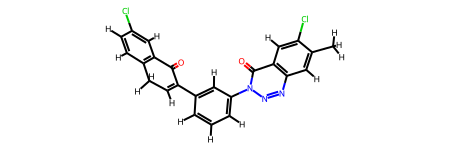

In [14]:
molec.mol # rdkit mol object